# Favorita 02 — Temporal Sales and Coverage EDA

## tl;dr

This descriptive notebook performs complete, chunked aggregations over `train.csv` while retaining only compact daily, weekly, store, item, family, promotion, and store-item summaries. It investigates coverage and potential research-scope risks; it creates no model features or predictions.

Run Notebook 01 first. Charts are aggregate-only SVG files under ignored `artifacts/reports/favorita_eda/plots/`. They use a standard-library renderer because matplotlib is not part of the repository dependency contract.


## Context & Methods

The analysis is descriptive. Full aggregation supports population totals and coverage findings. No causal effect is attributed to promotion, holidays, transactions, or oil: comparisons and correlations may reflect confounding, selection, missingness, or time trends.

### Key assumptions

- A row is an observed store-item-date sale record; absence of a row is not automatically zero demand.
- Negative `unit_sales` values remain unmodified and may represent returns or corrections; policy is unresolved.
- Store-item activity is measured from observed rows, not from an artificially densified calendar.
- Holiday data is aggregated to date before joining, preventing many-to-many row multiplication.


### 1. Configure bounded execution and plotting fallback


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import time

import numpy as np
import pandas as pd

from IPython.display import SVG, display

EDA_MODE = "bounded"
TRAIN_CHUNKSIZE = 1_000_000
MAX_SAMPLE_ROWS = 250_000
RANDOM_SEED = 42

if EDA_MODE != "bounded":
    raise ValueError("This research batch permits only EDA_MODE='bounded'.")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "requirements.txt").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the EDIP repository.")

REPO_ROOT = find_repo_root(Path.cwd())
RAW_DIR = REPO_ROOT / "data" / "raw" / "favorita-grocery-sales-forecasting"
EVIDENCE_DIR = REPO_ROOT / "artifacts" / "reports" / "favorita_eda"

EXPECTED_FILES = (
    "train.csv",
    "test.csv",
    "stores.csv",
    "items.csv",
    "transactions.csv",
    "holidays_events.csv",
    "oil.csv",
    "sample_submission.csv",
)

SOURCE_URL = "https://www.kaggle.com/competitions/favorita-grocery-sales-forecasting"
ANALYSIS_STARTED_AT = datetime.now(timezone.utc).isoformat()

def show_frame(frame: pd.DataFrame, rows: int = 10) -> None:
    """Print a bounded table that also works outside an interactive kernel."""
    print(frame.head(rows).to_string(index=False))

print({
    "eda_mode": EDA_MODE,
    "train_chunksize": TRAIN_CHUNKSIZE,
    "max_sample_rows": MAX_SAMPLE_ROWS,
    "random_seed": RANDOM_SEED,
    "raw_dir": RAW_DIR.as_posix(),
    "analysis_started_at_utc": ANALYSIS_STARTED_AT,
})


QUALITY_PATH = EVIDENCE_DIR / "01_data_inventory_and_quality_summary.json"
if not QUALITY_PATH.is_file():
    raise FileNotFoundError("Run Notebook 01 first; its aggregate-only quality summary is required.")
quality_evidence = json.loads(QUALITY_PATH.read_text(encoding="utf-8"))

def add_series(current: pd.Series | None, update: pd.Series) -> pd.Series:
    update = update.astype("float64")
    return update if current is None else current.add(update, fill_value=0.0)

def update_min(target: dict, keys, values) -> None:
    for key, value in zip(keys, values):
        text = str(value)
        if key not in target or text < target[key]:
            target[key] = text

def update_max(target: dict, keys, values) -> None:
    for key, value in zip(keys, values):
        text = str(value)
        if key not in target or text > target[key]:
            target[key] = text

def svg_escape(value) -> str:
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def build_svg_line_chart(x_labels, values, title: str, x_label: str, y_label: str, source_note: str) -> str:
    width, height = 960, 520
    left, right, top, bottom = 90, 30, 60, 90
    values = [float(v) for v in values]
    if not values:
        raise ValueError("Cannot plot an empty series")
    y_min, y_max = min(values), max(values)
    if y_max == y_min:
        y_max = y_min + 1.0
    points = []
    for index, value in enumerate(values):
        x = left + (width - left - right) * index / max(1, len(values) - 1)
        y = top + (height - top - bottom) * (y_max - value) / (y_max - y_min)
        points.append(f"{x:.1f},{y:.1f}")
    ticks = []
    for fraction in (0.0, 0.25, 0.5, 0.75, 1.0):
        y = top + (height - top - bottom) * (1 - fraction)
        value = y_min + (y_max - y_min) * fraction
        ticks.append(f'<line x1="{left}" y1="{y:.1f}" x2="{width-right}" y2="{y:.1f}" stroke="#dddddd"/><text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11">{value:,.0f}</text>')
    label_positions = sorted(set([0, len(x_labels)//4, len(x_labels)//2, 3*len(x_labels)//4, len(x_labels)-1]))
    x_ticks = []
    for index in label_positions:
        x = left + (width - left - right) * index / max(1, len(x_labels) - 1)
        x_ticks.append(f'<text x="{x:.1f}" y="{height-bottom+24}" text-anchor="middle" font-size="11">{svg_escape(x_labels[index])}</text>')
    svg = f"""<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">
    <rect width="100%" height="100%" fill="white"/>
    <text x="{width/2}" y="30" text-anchor="middle" font-size="18" font-weight="bold">{svg_escape(title)}</text>
    {''.join(ticks)}
    <line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#333333"/>
    <line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#333333"/>
    <polyline fill="none" stroke="#205493" stroke-width="2" points="{' '.join(points)}"/>
    {''.join(x_ticks)}
    <text x="{width/2}" y="{height-45}" text-anchor="middle" font-size="12">{svg_escape(x_label)}</text>
    <text x="18" y="{height/2}" text-anchor="middle" transform="rotate(-90 18 {height/2})" font-size="12">{svg_escape(y_label)}</text>
    <text x="{left}" y="{height-15}" font-size="10" fill="#555555">{svg_escape(source_note)}</text>
    </svg>"""
    return svg

def build_svg_bar_chart(labels, values, title: str, x_label: str, y_label: str, source_note: str) -> str:
    width, height = 960, 560
    left, right, top, bottom = 90, 30, 60, 140
    values = [float(v) for v in values]
    y_max = max(values) if values else 1.0
    bar_width = (width - left - right) / max(1, len(values)) * 0.72
    bars = []
    for index, (label, value) in enumerate(zip(labels, values)):
        x = left + (width-left-right) * (index + 0.14) / max(1, len(values))
        h = (height-top-bottom) * value / max(1.0, y_max)
        y = height-bottom-h
        bars.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_width:.1f}" height="{h:.1f}" fill="#205493"/><text x="{x+bar_width/2:.1f}" y="{height-bottom+16}" text-anchor="end" transform="rotate(-45 {x+bar_width/2:.1f} {height-bottom+16})" font-size="10">{svg_escape(label)}</text>')
    svg = f"""<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">
    <rect width="100%" height="100%" fill="white"/>
    <text x="{width/2}" y="30" text-anchor="middle" font-size="18" font-weight="bold">{svg_escape(title)}</text>
    <line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#333333"/>
    <line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#333333"/>
    {''.join(bars)}
    <text x="{width/2}" y="{height-48}" text-anchor="middle" font-size="12">{svg_escape(x_label)}</text>
    <text x="18" y="{height/2}" text-anchor="middle" transform="rotate(-90 18 {height/2})" font-size="12">{svg_escape(y_label)}</text>
    <text x="{left}" y="{height-15}" font-size="10" fill="#555555">{svg_escape(source_note)}</text>
    </svg>"""
    return svg


{'eda_mode': 'bounded', 'train_chunksize': 1000000, 'max_sample_rows': 250000, 'random_seed': 42, 'raw_dir': '/mnt/d/my_AI_projects/enterprise_decision_intelligence_platform_EDIP/data/raw/favorita-grocery-sales-forecasting', 'analysis_started_at_utc': '2026-08-07T09:50:12.644754+00:00'}


## Data

### 2. Load small dimensions and validate Notebook 01 evidence


In [2]:
required_sources = set(EXPECTED_FILES)
recorded_sources = set(quality_evidence["provenance"]["source_files"])
if recorded_sources != required_sources:
    raise ValueError("Notebook 01 evidence does not cover the expected source set.")
if quality_evidence["provenance"].get("contains_raw_records") is not False:
    raise ValueError("Notebook 01 evidence boundary is not aggregate-only.")

items = pd.read_csv(RAW_DIR / "items.csv", dtype={"item_nbr": "int32", "family": "string", "class": "int16", "perishable": "int8"})
stores = pd.read_csv(RAW_DIR / "stores.csv", dtype={"store_nbr": "int16", "city": "string", "state": "string", "type": "string", "cluster": "int16"})
transactions = pd.read_csv(RAW_DIR / "transactions.csv", dtype={"store_nbr": "int16", "transactions": "int32"}, parse_dates=["date"])
holidays = pd.read_csv(RAW_DIR / "holidays_events.csv", dtype={"type": "string", "locale": "string", "locale_name": "string", "description": "string", "transferred": "boolean"}, parse_dates=["date"])
oil = pd.read_csv(RAW_DIR / "oil.csv", dtype={"dcoilwtico": "float64"}, parse_dates=["date"])
item_family = items.set_index("item_nbr")["family"]
print({"quality_evidence_generated_at": quality_evidence["provenance"]["generated_at_utc"], "items": len(items), "stores": len(stores)})


{'quality_evidence_generated_at': '2026-08-03T09:34:43.701409+00:00', 'items': 4100, 'stores': 54}


## Results

### 3. Complete chunked temporal and coverage aggregation

Expected cost is a sequential read of approximately 5 GB. The aggregation retains daily/store/item/family series and one compact record per observed store-item pair. It does not retain raw rows.


In [3]:
daily_sales = daily_rows = None
store_sales = store_rows = None
item_sales = item_rows = None
family_sales = family_rows = None
store_item_rows = store_item_sales = None
daily_store_sales = None
promotion_sales = promotion_rows = None
item_first, item_last = {}, {}
series_first, series_last = {}, {}
total_rows = zero_rows = 0
aggregation_started = time.perf_counter()

for chunk_index, chunk in enumerate(pd.read_csv(
    RAW_DIR / "train.csv",
    usecols=["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"],
    dtype={"store_nbr": "int16", "item_nbr": "int32", "unit_sales": "float64", "onpromotion": "boolean"},
    chunksize=TRAIN_CHUNKSIZE,
)):
    total_rows += len(chunk)
    zero_rows += int((chunk["unit_sales"] == 0).sum())

    daily_group = chunk.groupby("date", sort=False)["unit_sales"].agg(["sum", "count"])
    daily_sales = add_series(daily_sales, daily_group["sum"])
    daily_rows = add_series(daily_rows, daily_group["count"])

    store_group = chunk.groupby("store_nbr", sort=False)["unit_sales"].agg(["sum", "count"])
    store_sales = add_series(store_sales, store_group["sum"])
    store_rows = add_series(store_rows, store_group["count"])

    item_group = chunk.groupby("item_nbr", sort=False)["unit_sales"].agg(["sum", "count"])
    item_sales = add_series(item_sales, item_group["sum"])
    item_rows = add_series(item_rows, item_group["count"])

    families = chunk["item_nbr"].map(item_family)
    if families.isna().any():
        raise ValueError("Unmatched item encountered during family aggregation.")
    family_frame = pd.DataFrame({"family": families, "unit_sales": chunk["unit_sales"]})
    family_group = family_frame.groupby("family", sort=False)["unit_sales"].agg(["sum", "count"])
    family_sales = add_series(family_sales, family_group["sum"])
    family_rows = add_series(family_rows, family_group["count"])

    pair_group = chunk.groupby(["store_nbr", "item_nbr"], sort=False)["unit_sales"].agg(["sum", "count"])
    store_item_sales = add_series(store_item_sales, pair_group["sum"])
    store_item_rows = add_series(store_item_rows, pair_group["count"])

    date_store = chunk.groupby(["date", "store_nbr"], sort=False)["unit_sales"].sum()
    daily_store_sales = add_series(daily_store_sales, date_store)

    promotion_label = chunk["onpromotion"].astype("string").fillna("missing")
    promotion_group = pd.DataFrame({"promotion": promotion_label, "unit_sales": chunk["unit_sales"]}).groupby("promotion")["unit_sales"].agg(["sum", "count"])
    promotion_sales = add_series(promotion_sales, promotion_group["sum"])
    promotion_rows = add_series(promotion_rows, promotion_group["count"])

    item_dates = chunk.groupby("item_nbr")["date"].agg(["min", "max"])
    update_min(item_first, item_dates.index.tolist(), item_dates["min"].tolist())
    update_max(item_last, item_dates.index.tolist(), item_dates["max"].tolist())
    pair_dates = chunk.groupby(["store_nbr", "item_nbr"])["date"].agg(["min", "max"])
    update_min(series_first, pair_dates.index.tolist(), pair_dates["min"].tolist())
    update_max(series_last, pair_dates.index.tolist(), pair_dates["max"].tolist())

    if (chunk_index + 1) % 25 == 0:
        print(f"aggregated_chunks={chunk_index + 1}, rows={total_rows:,}, observed_series={len(store_item_rows):,}")

aggregation_seconds = time.perf_counter() - aggregation_started
expected_rows = int(quality_evidence["train"]["rows"])
if total_rows != expected_rows:
    raise ValueError(f"Row reconciliation failed: {total_rows:,} != {expected_rows:,}")
print({"rows": total_rows, "observed_store_item_series": len(store_item_rows), "seconds": round(aggregation_seconds, 3)})


aggregated_chunks=25, rows=25,000,000, observed_series=95,854


aggregated_chunks=50, rows=50,000,000, observed_series=116,607


aggregated_chunks=75, rows=75,000,000, observed_series=145,390


aggregated_chunks=100, rows=100,000,000, observed_series=161,716


aggregated_chunks=125, rows=125,000,000, observed_series=174,452


{'rows': 125497040, 'observed_store_item_series': 174685, 'seconds': 591.616}


### 4. Temporal totals, seasonality, and exceptional periods


In [4]:
daily = pd.DataFrame({"unit_sales": daily_sales, "observed_rows": daily_rows})
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()
weekly = daily["unit_sales"].resample("W-SUN").sum()
monthly = daily["unit_sales"].resample("ME").sum()
monthly_change = monthly.pct_change().replace([np.inf, -np.inf], np.nan)
largest_monthly_changes = monthly_change.abs().nlargest(8).index
structural_break_candidates = pd.DataFrame({
    "month": largest_monthly_changes.strftime("%Y-%m"),
    "unit_sales": monthly.loc[largest_monthly_changes].values,
    "month_over_month_change": monthly_change.loc[largest_monthly_changes].values,
}).sort_values("month")

weekday = daily.assign(weekday=daily.index.day_name()).groupby("weekday")["unit_sales"].mean().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])
print("Largest absolute month-over-month changes are descriptive review candidates, not proven structural breaks:")
show_frame(structural_break_candidates, rows=8)
print("\nMean daily sales by weekday:")
print(weekday.to_string())


Largest absolute month-over-month changes are descriptive review candidates, not proven structural breaks:
  month   unit_sales  month_over_month_change
2014-02 1.203834e+07                -0.363443
2014-03 2.036558e+07                 0.691727
2014-04 1.286125e+07                -0.368481
2014-07 1.942189e+07                 0.458105
2014-08 1.388515e+07                -0.285077
2014-09 2.002241e+07                 0.442002
2015-01 1.489692e+07                -0.387977
2017-08 1.243332e+07                -0.539702

Mean daily sales by weekday:
weekday
Monday       617479.929934
Tuesday      569916.489993
Wednesday    593244.190965
Thursday     505256.688612
Friday       579573.986125
Saturday     772147.340838
Sunday       825218.075771


**Partial-period caveat:** August 2017 contains observations only through 2017-08-15. Its month-over-month change is an incomplete-period artifact and must be excluded from any structural-break conclusion. The other large changes remain descriptive review candidates requiring domain context.


## 5. Product-level and store-level temporal sales patterns

Company-wide totals can hide product-specific and store-specific behaviour: an individual product can peak while total company sales declines. The selected top-N products and stores are bounded descriptive examples, not the complete forecasting population. Missing product-date or store-date rows are not automatically zero sales, August 2017 is partial, and all results below are descriptive rather than causal. This analysis does not approve the final modelling grain.


In [5]:
TOP_N_PRODUCTS = 10
MAX_DAILY_PRODUCT_LINES = 5
SELECTED_ITEM_NBRS = []

TOP_N_STORES = 10
SELECTED_STORE_NBRS = []
MAX_PLOTTED_SERIES = 10

pd.set_option("display.max_rows", TOP_N_PRODUCTS * 12)
pd.set_option("display.max_columns", None)

def resolve_bounded_ids(explicit_ids, ranking: pd.Series, top_n: int, label: str) -> list[int]:
    if not 1 <= top_n <= MAX_PLOTTED_SERIES:
        raise ValueError(f"{label} top-N must be between 1 and {MAX_PLOTTED_SERIES}.")
    unique_explicit = list(dict.fromkeys(int(value) for value in explicit_ids))
    if len(unique_explicit) > MAX_PLOTTED_SERIES:
        raise ValueError(f"{label} explicit selection exceeds {MAX_PLOTTED_SERIES} identifiers.")
    valid_ids = set(int(value) for value in ranking.index)
    missing_ids = sorted(set(unique_explicit) - valid_ids)
    if missing_ids:
        raise ValueError(f"Unknown {label} identifiers: {missing_ids}")
    return unique_explicit or [int(value) for value in ranking.sort_values(ascending=False).head(top_n).index]

def matrix_to_long(frame: pd.DataFrame, identifier: str, period_column: str) -> pd.DataFrame:
    long_frame = frame.rename_axis(index=period_column, columns=identifier).reset_index().melt(
        id_vars=period_column,
        var_name=identifier,
        value_name="unit_sales",
    )
    long_frame = long_frame.dropna(subset=["unit_sales"]).sort_values([identifier, period_column]).reset_index(drop=True)
    long_frame[identifier] = long_frame[identifier].astype("int64")
    return long_frame

def complete_week_mask(index: pd.DatetimeIndex) -> np.ndarray:
    return ((index - pd.Timedelta(days=6)) >= train_start) & (index <= train_end)

def complete_month_mask(index: pd.DatetimeIndex) -> np.ndarray:
    mask = np.ones(len(index), dtype=bool)
    if train_start.day != 1:
        mask &= index.to_period("M") != train_start.to_period("M")
    if not train_end.is_month_end:
        mask &= index.to_period("M") != train_end.to_period("M")
    return mask

def percentage_change(latest: float, previous: float) -> float | None:
    if pd.isna(previous) or previous == 0:
        return None
    return float((latest - previous) / previous)

def period_behaviour_summary(frame: pd.DataFrame, identifier: str, period_name: str, date_format: str) -> pd.DataFrame:
    rows = []
    for series_id in frame.columns:
        values = frame[series_id].dropna()
        peak_period = values.idxmax()
        lowest_period = values.idxmin()
        latest_period = values.index[-1]
        previous_period = values.index[-2] if len(values) >= 2 else None
        latest_value = float(values.iloc[-1])
        previous_value = float(values.iloc[-2]) if len(values) >= 2 else None
        rows.append({
            identifier: int(series_id),
            f"mean_{period_name}_sales": float(values.mean()),
            f"median_{period_name}_sales": float(values.median()),
            f"{period_name}_sales_std": float(values.std()),
            f"minimum_{period_name}_sales": float(values.min()),
            f"maximum_{period_name}_sales": float(values.max()),
            "peak_period": peak_period.strftime(date_format),
            "peak_period_sales": float(values.loc[peak_period]),
            "lowest_period": lowest_period.strftime(date_format),
            "lowest_period_sales": float(values.loc[lowest_period]),
            "latest_period": latest_period.strftime(date_format),
            "latest_period_sales": latest_value,
            "previous_period": previous_period.strftime(date_format) if previous_period is not None else None,
            "previous_period_sales": previous_value,
            "latest_period_change_pct": percentage_change(latest_value, previous_value),
            "observed_period_count": int(len(values)),
        })
    return pd.DataFrame(rows)


In [6]:
analyzed_item_nbrs = resolve_bounded_ids(SELECTED_ITEM_NBRS, item_sales, TOP_N_PRODUCTS, "product")
analyzed_store_nbrs = resolve_bounded_ids(SELECTED_STORE_NBRS, store_sales, TOP_N_STORES, "store")
daily_product_plot_item_nbrs = analyzed_item_nbrs[:MAX_DAILY_PRODUCT_LINES]

if not 1 <= MAX_DAILY_PRODUCT_LINES <= len(analyzed_item_nbrs):
    raise ValueError("MAX_DAILY_PRODUCT_LINES must be between 1 and the selected product count.")

selected_item_daily_sales = None
selected_item_stores = {item_nbr: set() for item_nbr in analyzed_item_nbrs}
product_scan_started = time.perf_counter()

for chunk in pd.read_csv(
    RAW_DIR / "train.csv",
    usecols=["date", "store_nbr", "item_nbr", "unit_sales"],
    dtype={"store_nbr": "int16", "item_nbr": "int32", "unit_sales": "float64"},
    chunksize=TRAIN_CHUNKSIZE,
):
    selected_rows = chunk[chunk["item_nbr"].isin(analyzed_item_nbrs)]
    if selected_rows.empty:
        continue
    daily_update = selected_rows.groupby(["date", "item_nbr"], sort=False)["unit_sales"].sum()
    selected_item_daily_sales = add_series(selected_item_daily_sales, daily_update)
    for item_nbr, store_values in selected_rows.groupby("item_nbr")["store_nbr"]:
        selected_item_stores[int(item_nbr)].update(int(value) for value in store_values.unique())

if selected_item_daily_sales is None:
    raise ValueError("The bounded product-date scan returned no observations.")

product_scan_seconds = time.perf_counter() - product_scan_started
additional_product_chunked_pass_required = True

product_daily_matrix = selected_item_daily_sales.rename("unit_sales").reset_index().pivot(
    index="date", columns="item_nbr", values="unit_sales"
)
product_daily_matrix.index = pd.to_datetime(product_daily_matrix.index)
product_daily_matrix = product_daily_matrix.sort_index().reindex(columns=analyzed_item_nbrs)
train_start = pd.Timestamp(product_daily_matrix.index.min())
train_end = pd.Timestamp(product_daily_matrix.index.max())
product_weekly_matrix = product_daily_matrix.resample("W-SUN").sum(min_count=1)
product_monthly_matrix = product_daily_matrix.resample("ME").sum(min_count=1)

product_daily_long = matrix_to_long(product_daily_matrix, "item_nbr", "date")
product_weekly_long = matrix_to_long(product_weekly_matrix, "item_nbr", "week_ending")
product_monthly_long = matrix_to_long(product_monthly_matrix, "item_nbr", "month_end")

store_daily_matrix = daily_store_sales.rename("unit_sales").reset_index().pivot(
    index="date", columns="store_nbr", values="unit_sales"
)
store_daily_matrix.index = pd.to_datetime(store_daily_matrix.index)
store_daily_matrix = store_daily_matrix.sort_index().reindex(columns=analyzed_store_nbrs)
store_weekly_matrix = store_daily_matrix.resample("W-SUN").sum(min_count=1)
store_monthly_matrix = store_daily_matrix.resample("ME").sum(min_count=1)

print({
    "observed_products": len(item_sales),
    "observed_stores": len(store_sales),
    "selected_product_ids": analyzed_item_nbrs,
    "daily_plot_product_ids": daily_product_plot_item_nbrs,
    "selected_store_ids": analyzed_store_nbrs,
    "additional_product_chunked_pass": additional_product_chunked_pass_required,
    "product_scan_seconds": round(product_scan_seconds, 3),
})


{'observed_products': 4036, 'observed_stores': 54, 'selected_product_ids': [1503844, 1047679, 1473474, 364606, 819932, 1463992, 807493, 265559, 502331, 314384], 'daily_plot_product_ids': [1503844, 1047679, 1473474, 364606, 819932], 'selected_store_ids': [44, 45, 47, 3, 49, 46, 48, 51, 8, 50], 'additional_product_chunked_pass': True, 'product_scan_seconds': 34.002}


In [7]:
def build_svg_multi_line_chart(frame: pd.DataFrame, title: str, x_label: str, y_label: str, source_note: str, partial_final_month: bool = False) -> str:
    width, height = 1000, 620
    left, right, top, bottom = 95, 35, 105, 95
    palette = ["#205493", "#2e8540", "#d83933", "#8a2be2", "#ff8c00", "#008b8b", "#795548", "#c2185b", "#607d8b", "#6b8e23"]
    finite_values = frame.to_numpy(dtype="float64")
    finite_values = finite_values[np.isfinite(finite_values)]
    if finite_values.size == 0:
        raise ValueError("Cannot plot an empty temporal frame.")
    y_min, y_max = float(finite_values.min()), float(finite_values.max())
    if y_max == y_min:
        y_max = y_min + 1.0
    plot_width = width - left - right
    plot_height = height - top - bottom
    series_elements = []
    legend_elements = []
    for series_index, column in enumerate(frame.columns):
        color = palette[series_index % len(palette)]
        points = []
        for index, value in enumerate(frame[column].tolist()):
            if pd.isna(value):
                continue
            x = left + plot_width * index / max(1, len(frame.index) - 1)
            y = top + plot_height * (y_max - float(value)) / (y_max - y_min)
            points.append(f"{x:.1f},{y:.1f}")
        series_elements.append(f'<polyline fill="none" stroke="{color}" stroke-width="1.7" points="{" ".join(points)}"/>')
        legend_x = left + (series_index % 5) * 170
        legend_y = 58 + (series_index // 5) * 24
        legend_elements.append(f'<line x1="{legend_x}" y1="{legend_y}" x2="{legend_x + 24}" y2="{legend_y}" stroke="{color}" stroke-width="3"/><text x="{legend_x + 30}" y="{legend_y + 4}" font-size="11">{svg_escape(column)}</text>')
    y_ticks = []
    for fraction in (0.0, 0.25, 0.5, 0.75, 1.0):
        y = top + plot_height * (1 - fraction)
        value = y_min + (y_max - y_min) * fraction
        y_ticks.append(f'<line x1="{left}" y1="{y:.1f}" x2="{width-right}" y2="{y:.1f}" stroke="#dddddd"/><text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11">{value:,.0f}</text>')
    label_positions = sorted(set([0, len(frame.index)//4, len(frame.index)//2, 3*len(frame.index)//4, len(frame.index)-1]))
    x_ticks = []
    for index in label_positions:
        x = left + plot_width * index / max(1, len(frame.index) - 1)
        label = frame.index[index].strftime("%Y-%m")
        if partial_final_month and frame.index[index].to_period("M") == train_end.to_period("M"):
            label += " (partial)"
        x_ticks.append(f'<text x="{x:.1f}" y="{height-bottom+24}" text-anchor="middle" font-size="11">{label}</text>')
    svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">
    <rect width="100%" height="100%" fill="white"/>  
    <text x="{width/2}" y="28" text-anchor="middle" font-size="18" font-weight="bold">{svg_escape(title)}</text>  
    {''.join(legend_elements)}{''.join(y_ticks)}  
    <line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#333333"/>
    <line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#333333"/>
    {''.join(series_elements)}{''.join(x_ticks)}
    <text x="{width/2}" y="{height-48}" text-anchor="middle" font-size="12">{svg_escape(x_label)}</text>
    <text x="18" y="{height/2}" text-anchor="middle" transform="rotate(-90 18 {height/2})" font-size="12">{svg_escape(y_label)}</text>
    <text x="{left}" y="{height-15}" font-size="10" fill="#555555">{svg_escape(source_note)}</text>
    </svg>'''
    return svg


### 5.1 Selected product metadata and coverage

The metadata table combines the governed item reference data with bounded descriptive statistics from product sales aggregated across all stores.


In [8]:
product_coverage = product_daily_long.groupby("item_nbr", as_index=False).agg(
    total_observed_unit_sales=("unit_sales", "sum"),
    first_observed_date=("date", "min"),
    last_observed_date=("date", "max"),
    observed_day_count=("date", "count"),
)
product_coverage["first_observed_date"] = product_coverage["first_observed_date"].dt.date.astype(str)
product_coverage["last_observed_date"] = product_coverage["last_observed_date"].dt.date.astype(str)
product_coverage["observed_store_count"] = product_coverage["item_nbr"].map(
    lambda item_nbr: len(selected_item_stores[int(item_nbr)])
)

product_summary = items[["item_nbr", "family", "class", "perishable"]].merge(
    product_coverage,
    on="item_nbr",
    how="inner",
    validate="one_to_one",
)
product_summary["selection_order"] = product_summary["item_nbr"].map(
    {item_nbr: index for index, item_nbr in enumerate(analyzed_item_nbrs)}
)
product_summary = product_summary.sort_values("selection_order").drop(columns="selection_order").reset_index(drop=True)
product_summary = product_summary[[
    "item_nbr",
    "family",
    "class",
    "perishable",
    "total_observed_unit_sales",
    "first_observed_date",
    "last_observed_date",
    "observed_day_count",
    "observed_store_count",
]]
display(product_summary)


,item_nbr,family,class,perishable,total_observed_unit_sales,first_observed_date,last_observed_date,observed_day_count,observed_store_count
0,1503844,PRODUCE,2022,1,6.264200e+06,2014-01-01,2017-08-15,1019,43
1,1047679,BEVERAGES,1120,0,5.512875e+06,2013-01-01,2017-08-15,1684,54
2,1473474,PRODUCE,2014,1,4.990323e+06,2014-01-01,2017-08-15,1019,53
3,364606,GROCERY I,1014,0,4.416426e+06,2013-01-01,2017-08-15,1684,54
4,819932,BEVERAGES,1122,0,4.410943e+06,2013-01-02,2017-08-15,1638,54
5,1463992,BEVERAGES,1144,0,4.408545e+06,2014-01-01,2017-08-15,1026,54
6,807493,BEVERAGES,1124,0,4.321424e+06,2013-01-01,2017-08-15,1676,54
7,265559,GROCERY I,1072,0,4.112827e+06,2013-01-01,2017-08-15,1684,54
8,502331,BREAD/BAKERY,2702,1,3.703350e+06,2013-01-01,2017-08-15,1684,54
9,314384,GROCERY I,1004,0,3.544341e+06,2013-01-01,2017-08-15,1684,54


### 5.2 Daily product behaviour

Daily statistics use observed product dates only; absent product-date rows remain missing rather than being imputed as zero. The daily graph is limited by `MAX_DAILY_PRODUCT_LINES` while the numerical table covers every selected product.


,item_nbr,mean_daily_sales,median_daily_sales,daily_sales_std,minimum_daily_sales,maximum_daily_sales,daily_sales_25th_percentile,daily_sales_75th_percentile,daily_sales_coefficient_of_variation,peak_sales_date,peak_day_unit_sales,lowest_observed_sales_date,lowest_observed_daily_unit_sales,observed_day_count,days_above_daily_mean
0,1503844,6147.399171,5944.964,1506.020797,60.8387,10074.297,5037.7665,7288.0790,0.244985,2016-04-03,10074.297,2014-01-01,60.8387,1019,474
1,1047679,3273.678741,3036.500,965.195416,32.0000,8991.000,2564.2500,3920.0000,0.294835,2017-03-14,8991.000,2013-01-01,32.0000,1684,704
2,1473474,4897.274431,4697.290,1057.675807,70.7620,7472.353,4133.6390,5761.3515,0.215972,2017-03-01,7472.353,2017-01-01,70.7620,1019,470
3,364606,2622.580760,2482.500,725.350930,5.0000,7949.000,2107.0000,3019.7500,0.276579,2014-12-18,7949.000,2013-01-01,5.0000,1684,719
4,819932,2692.883394,2675.500,967.170436,1.0000,8515.000,2134.2500,3210.2500,0.359158,2016-12-22,8515.000,2016-05-22,1.0000,1638,804
5,1463992,4296.827485,3874.500,1282.546250,7.0000,9400.000,3379.2500,5005.2500,0.298487,2016-04-03,9400.000,2014-01-01,7.0000,1026,395
6,807493,2578.415274,2493.000,1407.225109,1.0000,8048.000,1377.7500,3376.0000,0.545771,2015-03-01,8048.000,2016-06-08,1.0000,1676,795
7,265559,2442.296318,2206.500,1098.625619,2.0000,21819.000,1810.0000,2834.0000,0.449833,2016-04-21,21819.000,2013-01-01,2.0000,1684,674
8,502331,2199.138955,2034.500,650.694681,30.0000,4900.000,1713.7500,2512.0000,0.295886,2015-05-31,4900.000,2013-01-01,30.0000,1684,691
9,314384,2104.715558,1931.000,641.993728,7.0000,4708.000,1626.0000,2499.0000,0.305026,2016-04-03,4708.000,2014-01-01,7.0000,1684,692


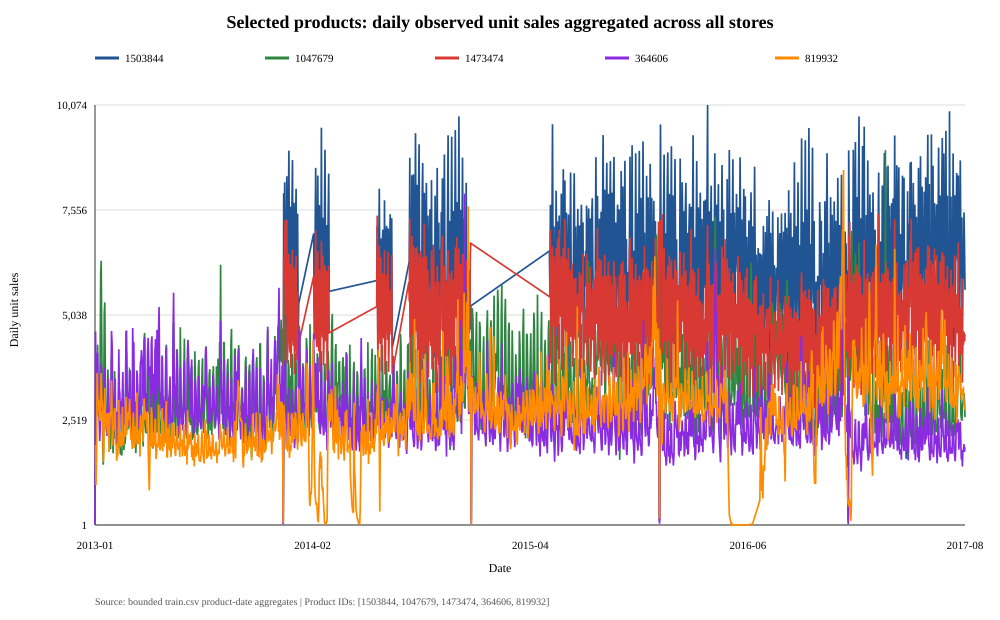

In [9]:
daily_product_rows = []
for item_nbr in analyzed_item_nbrs:
    values = product_daily_matrix[item_nbr].dropna()
    daily_mean = float(values.mean())
    daily_std = float(values.std())
    peak_date = values.idxmax()
    lowest_date = values.idxmin()
    daily_product_rows.append({
        "item_nbr": item_nbr,
        "mean_daily_sales": daily_mean,
        "median_daily_sales": float(values.median()),
        "daily_sales_std": daily_std,
        "minimum_daily_sales": float(values.min()),
        "maximum_daily_sales": float(values.max()),
        "daily_sales_25th_percentile": float(values.quantile(0.25)),
        "daily_sales_75th_percentile": float(values.quantile(0.75)),
        "daily_sales_coefficient_of_variation": float(daily_std / daily_mean) if daily_mean != 0 else None,
        "peak_sales_date": peak_date.date().isoformat(),
        "peak_day_unit_sales": float(values.loc[peak_date]),
        "lowest_observed_sales_date": lowest_date.date().isoformat(),
        "lowest_observed_daily_unit_sales": float(values.loc[lowest_date]),
        "observed_day_count": int(len(values)),
        "days_above_daily_mean": int((values > daily_mean).sum()),
    })
product_daily_behaviour = pd.DataFrame(daily_product_rows)
display(product_daily_behaviour)

product_daily_svg = build_svg_multi_line_chart(
    product_daily_matrix[daily_product_plot_item_nbrs],
    "Selected products: daily observed unit sales aggregated across all stores",
    "Date",
    "Daily unit sales",
    f"Source: bounded train.csv product-date aggregates | Product IDs: {daily_product_plot_item_nbrs}",
)
display(SVG(data=product_daily_svg))


### 5.3 Weekly product behaviour

Weekly totals use `W-SUN`. Statistics and latest-period comparisons exclude the incomplete boundary weeks.


,item_nbr,mean_weekly_sales,median_weekly_sales,weekly_sales_std,minimum_weekly_sales,maximum_weekly_sales,peak_week,peak_week_sales,lowest_week,lowest_week_sales,observed_week_count,latest_complete_week,latest_complete_week_sales,previous_complete_week,previous_complete_week_sales,latest_week_over_week_change_pct
0,1503844,41958.848440,43160.484,5925.568116,5606.932,48721.250,2017-05-07,48721.250,2014-04-06,5606.932,149,2017-08-13,42244.67,2017-08-06,47145.032,-0.103942
1,1047679,22879.304167,22052.000,3725.560811,15124.000,36906.000,2017-01-15,36906.000,2013-02-24,15124.000,240,2017-08-13,19677.00,2017-08-06,25437.000,-0.226442
2,1473474,33431.875264,34182.500,4486.636986,4609.708,41798.351,2016-01-10,41798.351,2014-04-06,4609.708,149,2017-08-13,31657.22,2017-08-06,34817.571,-0.090769
3,364606,18306.779167,17968.000,3053.100057,12111.000,30950.000,2016-04-24,30950.000,2017-08-13,12111.000,240,2017-08-13,12111.00,2017-08-06,15845.000,-0.235658
4,819932,18539.223629,19093.000,5962.016982,2.000,37825.000,2016-12-25,37825.000,2016-06-05,2.000,237,2017-08-13,21905.00,2017-08-06,24290.000,-0.098189
5,1463992,29145.225166,29391.000,4910.821777,555.000,38241.000,2016-03-27,38241.000,2015-05-10,555.000,151,2017-08-13,27758.00,2017-08-06,32421.000,-0.143827
6,807493,17902.683333,18535.000,8133.776964,27.000,32249.000,2014-01-05,32249.000,2016-06-05,27.000,240,2017-08-13,5987.00,2017-08-06,7115.000,-0.158538
7,265559,17057.979167,16172.000,5048.355944,10985.000,69361.000,2016-04-24,69361.000,2014-06-29,10985.000,240,2017-08-13,13836.00,2017-08-06,18924.000,-0.268865
8,502331,15353.262500,15173.500,1594.104332,11386.000,21367.000,2015-01-04,21367.000,2016-10-30,11386.000,240,2017-08-13,13299.00,2017-08-06,15243.000,-0.127534
9,314384,14706.758333,14557.000,2002.706353,10678.000,20463.000,2015-10-04,20463.000,2017-05-14,10678.000,240,2017-08-13,12197.00,2017-08-06,14343.000,-0.149620


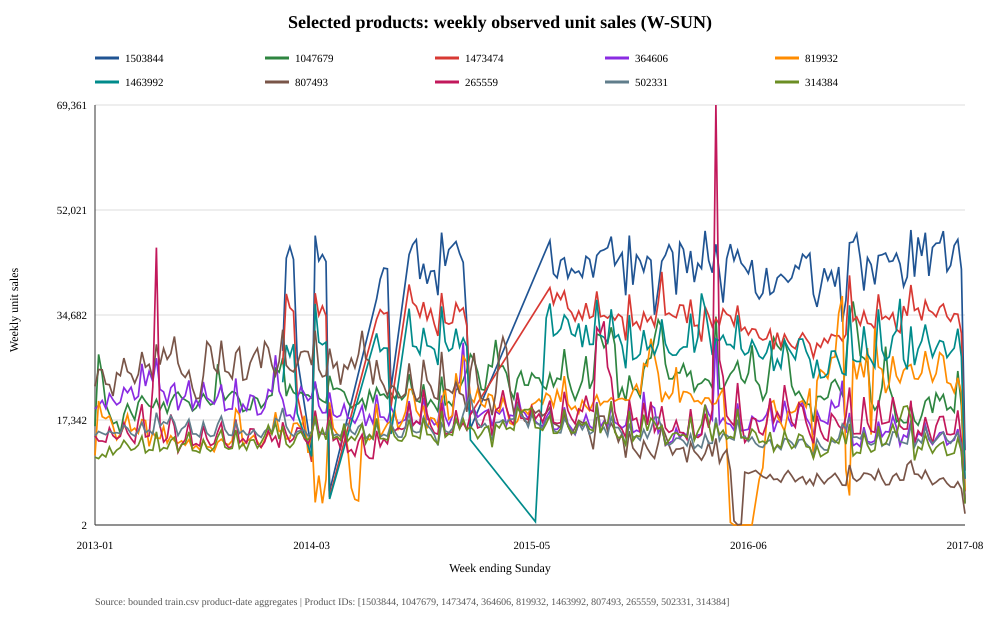

In [10]:
product_weekly_complete = product_weekly_matrix.loc[complete_week_mask(product_weekly_matrix.index)]
weekly_product_rows = []
for item_nbr in analyzed_item_nbrs:
    values = product_weekly_complete[item_nbr].dropna()
    peak_week = values.idxmax()
    lowest_week = values.idxmin()
    latest_week = values.index[-1]
    previous_week = values.index[-2]
    latest_sales = float(values.iloc[-1])
    previous_sales = float(values.iloc[-2])
    weekly_product_rows.append({
        "item_nbr": item_nbr,
        "mean_weekly_sales": float(values.mean()),
        "median_weekly_sales": float(values.median()),
        "weekly_sales_std": float(values.std()),
        "minimum_weekly_sales": float(values.min()),
        "maximum_weekly_sales": float(values.max()),
        "peak_week": peak_week.date().isoformat(),
        "peak_week_sales": float(values.loc[peak_week]),
        "lowest_week": lowest_week.date().isoformat(),
        "lowest_week_sales": float(values.loc[lowest_week]),
        "observed_week_count": int(len(values)),
        "latest_complete_week": latest_week.date().isoformat(),
        "latest_complete_week_sales": latest_sales,
        "previous_complete_week": previous_week.date().isoformat(),
        "previous_complete_week_sales": previous_sales,
        "latest_week_over_week_change_pct": percentage_change(latest_sales, previous_sales),
    })
product_weekly_behaviour = pd.DataFrame(weekly_product_rows)
display(product_weekly_behaviour)

product_weekly_svg = build_svg_multi_line_chart(
    product_weekly_matrix,
    "Selected products: weekly observed unit sales (W-SUN)",
    "Week ending Sunday",
    "Weekly unit sales",
    f"Source: bounded train.csv product-date aggregates | Product IDs: {analyzed_item_nbrs}",
)
display(SVG(data=product_weekly_svg))


### 5.4 Monthly product behaviour

August 2017 is a **partial month** because training observations end on 2017-08-15. It remains visible in the graph and is explicitly labelled there, but it is excluded from all complete-month statistics and comparisons.


,item_nbr,mean_complete_month_sales,median_complete_month_sales,monthly_sales_std,minimum_complete_month_sales,maximum_complete_month_sales,peak_month,peak_month_sales,lowest_complete_month,lowest_month_sales,latest_complete_month,latest_complete_month_sales,previous_complete_month,previous_complete_month_sales,latest_month_over_month_change_pct,largest_positive_month_over_month_change,month_of_largest_positive_change,largest_negative_month_over_month_change,month_of_largest_negative_change
0,1503844,186940.720352,188379.613,8774.470020,166053.060,203103.756,2017-07,203103.756,2017-02,166053.060,2017-07,203103.756,2017-06,191754.880,0.059184,0.168897,2017-03,-0.156099,2017-02
1,1047679,99360.200000,96961.000,13717.679960,67041.000,139246.000,2017-01,139246.000,2013-02,67041.000,2017-07,88504.000,2017-06,88684.000,-0.002030,0.335444,2015-12,-0.335557,2017-02
2,1473474,149074.853618,150980.995,9252.552955,126131.167,160623.232,2015-06,160623.232,2016-09,126131.167,2017-07,156851.543,2017-06,150087.164,0.045070,0.131978,2017-03,-0.105064,2017-02
3,364606,79765.036364,79370.000,11376.234722,57612.000,105560.000,2013-12,105560.000,2017-02,57612.000,2017-07,64938.000,2017-06,61170.000,0.061599,0.328020,2016-04,-0.325724,2017-01
4,819932,79310.981818,80632.000,24037.109444,27.000,127081.000,2016-12,127081.000,2016-06,27.000,2017-07,108893.000,2017-06,110934.000,-0.018398,1255.185185,2016-07,-0.999316,2016-06
5,1463992,127811.235294,130522.000,18299.078674,34747.000,142508.000,2016-03,142508.000,2015-05,34747.000,2017-07,133768.000,2017-06,125810.000,0.063254,3.030017,2015-06,-0.744869,2015-05
6,807493,78316.745455,85622.000,34410.771520,21479.000,124119.000,2013-12,124119.000,2016-06,21479.000,2017-07,31264.000,2017-06,32045.000,-0.024372,0.761395,2016-07,-0.410872,2016-06
7,265559,74152.963636,72719.000,14280.342944,54338.000,136902.000,2016-04,136902.000,2014-06,54338.000,2017-07,73945.000,2017-06,66714.000,0.108388,0.996296,2016-04,-0.393783,2015-10
8,502331,66787.436364,67190.000,5935.610452,55364.000,82877.000,2014-12,82877.000,2016-11,55364.000,2017-07,65896.000,2017-06,60639.000,0.086693,0.253558,2016-12,-0.141204,2017-02
9,314384,63928.509091,64936.000,7293.273847,49962.000,80789.000,2015-04,80789.000,2013-02,49962.000,2017-07,56617.000,2017-06,55357.000,0.022761,0.294964,2016-12,-0.257905,2017-05


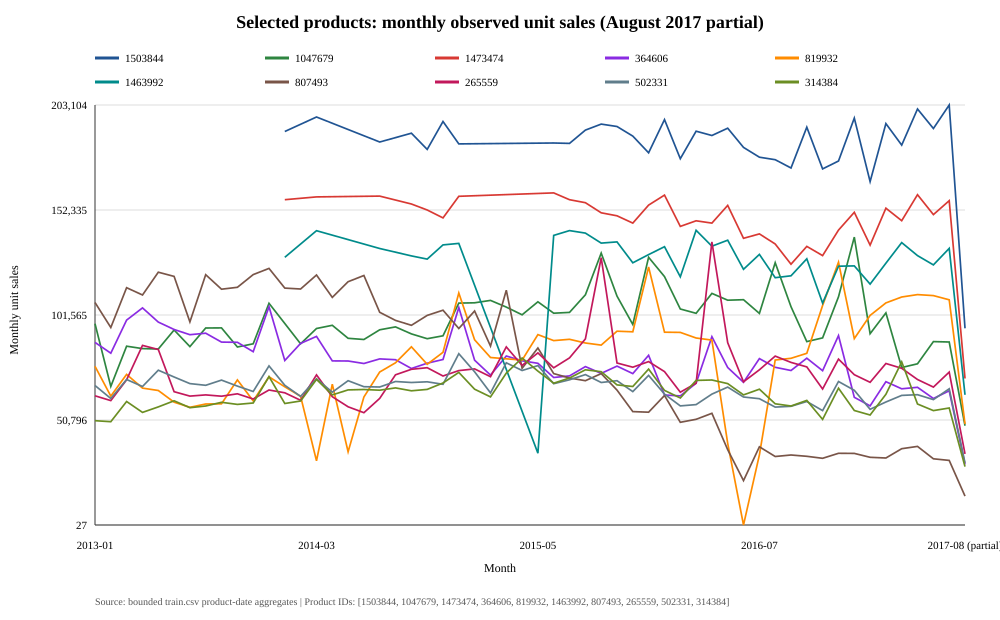

In [11]:
product_monthly_complete = product_monthly_matrix.loc[complete_month_mask(product_monthly_matrix.index)]
monthly_product_rows = []
for item_nbr in analyzed_item_nbrs:
    values = product_monthly_complete[item_nbr].dropna()
    previous_values = values.shift(1)
    monthly_change = ((values - previous_values) / previous_values.where(previous_values != 0)).dropna()
    positive_changes = monthly_change[monthly_change > 0]
    negative_changes = monthly_change[monthly_change < 0]
    peak_month = values.idxmax()
    lowest_month = values.idxmin()
    latest_month = values.index[-1]
    previous_month = values.index[-2]
    latest_sales = float(values.iloc[-1])
    previous_sales = float(values.iloc[-2])
    largest_positive_month = positive_changes.idxmax() if not positive_changes.empty else None
    largest_negative_month = negative_changes.idxmin() if not negative_changes.empty else None
    monthly_product_rows.append({
        "item_nbr": item_nbr,
        "mean_complete_month_sales": float(values.mean()),
        "median_complete_month_sales": float(values.median()),
        "monthly_sales_std": float(values.std()),
        "minimum_complete_month_sales": float(values.min()),
        "maximum_complete_month_sales": float(values.max()),
        "peak_month": peak_month.strftime("%Y-%m"),
        "peak_month_sales": float(values.loc[peak_month]),
        "lowest_complete_month": lowest_month.strftime("%Y-%m"),
        "lowest_month_sales": float(values.loc[lowest_month]),
        "latest_complete_month": latest_month.strftime("%Y-%m"),
        "latest_complete_month_sales": latest_sales,
        "previous_complete_month": previous_month.strftime("%Y-%m"),
        "previous_complete_month_sales": previous_sales,
        "latest_month_over_month_change_pct": percentage_change(latest_sales, previous_sales),
        "largest_positive_month_over_month_change": float(positive_changes.loc[largest_positive_month]) if largest_positive_month is not None else None,
        "month_of_largest_positive_change": largest_positive_month.strftime("%Y-%m") if largest_positive_month is not None else None,
        "largest_negative_month_over_month_change": float(negative_changes.loc[largest_negative_month]) if largest_negative_month is not None else None,
        "month_of_largest_negative_change": largest_negative_month.strftime("%Y-%m") if largest_negative_month is not None else None,
    })
product_monthly_behaviour = pd.DataFrame(monthly_product_rows)
display(product_monthly_behaviour)

product_monthly_svg = build_svg_multi_line_chart(
    product_monthly_matrix,
    "Selected products: monthly observed unit sales (August 2017 partial)",
    "Month",
    "Monthly unit sales",
    f"Source: bounded train.csv product-date aggregates | Product IDs: {analyzed_item_nbrs}",
    partial_final_month=True,
)
display(SVG(data=product_monthly_svg))


### 5.5 Detailed complete-month product movements

These bounded positive and negative changes are descriptive month-to-month movements, not proven structural breaks.


In [12]:
product_monthly_complete_long = matrix_to_long(product_monthly_complete, "item_nbr", "month_end")
product_monthly_movements = product_monthly_complete_long.sort_values(["item_nbr", "month_end"]).copy()
product_monthly_movements["previous_month_unit_sales"] = product_monthly_movements.groupby("item_nbr")["unit_sales"].shift(1)
product_monthly_movements["absolute_sales_change"] = (
    product_monthly_movements["unit_sales"] - product_monthly_movements["previous_month_unit_sales"]
)
valid_previous = product_monthly_movements["previous_month_unit_sales"].where(
    product_monthly_movements["previous_month_unit_sales"] != 0
)
product_monthly_movements["month_over_month_percentage_change"] = (
    product_monthly_movements["absolute_sales_change"] / valid_previous
)
product_monthly_movements = product_monthly_movements.merge(
    items[["item_nbr", "family"]], on="item_nbr", how="left", validate="many_to_one"
)
product_monthly_movements["month"] = product_monthly_movements["month_end"].dt.strftime("%Y-%m")
movement_columns = [
    "item_nbr", "family", "month", "unit_sales", "previous_month_unit_sales",
    "absolute_sales_change", "month_over_month_percentage_change",
]
top_positive_product_month_changes = product_monthly_movements[
    product_monthly_movements["month_over_month_percentage_change"] > 0
].nlargest(10, "month_over_month_percentage_change")[movement_columns].reset_index(drop=True)
top_negative_product_month_changes = product_monthly_movements[
    product_monthly_movements["month_over_month_percentage_change"] < 0
].nsmallest(10, "month_over_month_percentage_change")[movement_columns].reset_index(drop=True)

display(top_positive_product_month_changes)
display(top_negative_product_month_changes)


,item_nbr,family,month,unit_sales,previous_month_unit_sales,absolute_sales_change,month_over_month_percentage_change
0,819932,BEVERAGES,2016-07,33917.0,27.0,33890.0,1255.185185
1,1463992,BEVERAGES,2015-06,140031.0,34747.0,105284.0,3.030017
2,819932,BEVERAGES,2016-08,79798.0,33917.0,45881.0,1.352743
3,819932,BEVERAGES,2014-04,68116.0,31078.0,37038.0,1.191776
4,265559,GROCERY I,2016-04,136902.0,68578.0,68324.0,0.996296
5,807493,BEVERAGES,2016-07,37833.0,21479.0,16354.0,0.761395
6,819932,BEVERAGES,2014-06,61933.0,35404.0,26529.0,0.749322
7,265559,GROCERY I,2015-09,129264.0,90004.0,39260.0,0.436203
8,819932,BEVERAGES,2014-12,112205.0,83533.0,28672.0,0.343242
9,1047679,BEVERAGES,2015-12,129486.0,96961.0,32525.0,0.335444


,item_nbr,family,month,unit_sales,previous_month_unit_sales,absolute_sales_change,month_over_month_percentage_change
0,819932,BEVERAGES,2016-06,27.0,39487.0,-39460.0,-0.999316
1,1463992,BEVERAGES,2015-05,34747.0,136193.0,-101446.0,-0.744869
2,819932,BEVERAGES,2016-05,39487.0,89418.0,-49931.0,-0.558400
3,819932,BEVERAGES,2014-03,31078.0,62276.0,-31198.0,-0.500963
4,819932,BEVERAGES,2014-05,35404.0,68116.0,-32712.0,-0.480240
5,807493,BEVERAGES,2016-06,21479.0,36459.0,-14980.0,-0.410872
6,265559,GROCERY I,2015-10,78362.0,129264.0,-50902.0,-0.393783
7,265559,GROCERY I,2016-05,88162.0,136902.0,-48740.0,-0.356021
8,1047679,BEVERAGES,2017-02,92521.0,139246.0,-46725.0,-0.335557
9,807493,BEVERAGES,2015-04,75788.0,113542.0,-37754.0,-0.332511


### 5.6 Product seasonality profiles

Weekday profiles compare observed product days. Calendar-month profiles use complete months only and exclude partial August 2017.


In [13]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
product_weekday_source = product_daily_long.assign(
    weekday=product_daily_long["date"].dt.day_name(),
    weekday_number=product_daily_long["date"].dt.dayofweek,
)
product_weekday_profile = product_weekday_source.groupby(
    ["item_nbr", "weekday_number", "weekday"], as_index=False
)["unit_sales"].agg(
    mean_daily_sales="mean",
    median_daily_sales="median",
    total_sales="sum",
    observed_day_count="count",
)
product_weekday_profile["weekday_sales_share"] = (
    product_weekday_profile["total_sales"]
    / product_weekday_profile.groupby("item_nbr")["total_sales"].transform("sum")
)
product_weekday_profile["weekday"] = pd.Categorical(
    product_weekday_profile["weekday"], categories=weekday_order, ordered=True
)
product_weekday_profile = product_weekday_profile.sort_values(["item_nbr", "weekday_number"]).drop(
    columns="weekday_number"
).reset_index(drop=True)

product_calendar_month_source = product_monthly_complete_long.assign(
    calendar_month_number=product_monthly_complete_long["month_end"].dt.month,
    calendar_month_name=product_monthly_complete_long["month_end"].dt.month_name(),
)
product_calendar_month_profile = product_calendar_month_source.groupby(
    ["item_nbr", "calendar_month_number", "calendar_month_name"], as_index=False
)["unit_sales"].agg(
    mean_monthly_sales="mean",
    median_monthly_sales="median",
    complete_observation_count="count",
    calendar_month_total_sales="sum",
)
product_calendar_month_profile["calendar_month_sales_share"] = (
    product_calendar_month_profile["calendar_month_total_sales"]
    / product_calendar_month_profile.groupby("item_nbr")["calendar_month_total_sales"].transform("sum")
)
product_calendar_month_profile = product_calendar_month_profile.drop(
    columns="calendar_month_total_sales"
).sort_values(["item_nbr", "calendar_month_number"]).reset_index(drop=True)

display(product_weekday_profile)
display(product_calendar_month_profile)


,item_nbr,weekday,mean_daily_sales,median_daily_sales,total_sales,observed_day_count,weekday_sales_share
0,265559,Monday,2518.095436,2300.0000,6.068610e+05,241,0.147553
1,265559,Tuesday,2224.479339,2029.0000,5.383240e+05,242,0.130889
2,265559,Wednesday,2093.566667,1941.5000,5.024560e+05,240,0.122168
3,265559,Thursday,1932.375000,1740.0000,4.637700e+05,240,0.112762
4,265559,Friday,1981.929167,1834.0000,4.756630e+05,240,0.115654
5,265559,Saturday,2912.800830,2784.0000,7.019850e+05,241,0.170682
6,265559,Sunday,3432.366667,3400.0000,8.237680e+05,240,0.200292
7,314384,Monday,2060.742739,1973.0000,4.966390e+05,241,0.140122
8,314384,Tuesday,1854.099174,1785.0000,4.486920e+05,242,0.126594
9,314384,Wednesday,1861.441667,1798.5000,4.467460e+05,240,0.126045


,item_nbr,calendar_month_number,calendar_month_name,mean_monthly_sales,median_monthly_sales,complete_observation_count,calendar_month_sales_share
0,265559,1,January,69777.200000,72719.0000,5,0.085545
1,265559,2,February,65096.000000,64248.0000,5,0.079806
2,265559,3,March,75119.800000,72586.0000,5,0.092094
3,265559,4,April,87767.400000,77201.0000,5,0.107600
4,265559,5,May,76762.000000,83236.0000,5,0.094108
5,265559,6,June,66164.400000,66714.0000,5,0.081115
6,265559,7,July,70688.200000,73945.0000,5,0.086661
7,265559,8,August,76816.500000,77160.0000,4,0.075340
8,265559,9,September,86386.250000,76980.5000,4,0.084725
9,265559,10,October,73595.000000,76287.0000,4,0.072180


### 5.7 Daily store behaviour

Store-date aggregates are reused from the original complete chunked pass; no additional raw-data pass is needed for stores.


,store_nbr,mean_daily_sales,median_daily_sales,daily_sales_std,minimum_daily_sales,maximum_daily_sales,peak_period,peak_period_sales,lowest_period,lowest_period_sales,latest_period,latest_period_sales,previous_period,previous_period_sales,latest_period_change_pct,observed_period_count
0,44,36978.882819,35452.082,14587.834797,9067.748,90557.925,2016-04-17,90557.925,2013-06-11,9067.748,2017-08-15,33141.322,2017-08-14,35617.528,-0.069522,1679
1,45,32458.612517,30858.737,13595.411189,2741.898,114144.378,2016-04-18,114144.378,2017-04-03,2741.898,2017-08-15,31562.926,2017-08-14,35065.714,-0.099892,1679
2,47,30344.436010,28966.293,12432.322618,10279.394,75297.955,2017-06-04,75297.955,2013-06-27,10279.394,2017-08-15,31653.691,2017-08-14,31814.268,-0.005047,1679
3,3,30066.646328,29569.358,11222.066836,11454.688,69516.386,2017-04-01,69516.386,2013-01-24,11454.688,2017-08-15,30185.602,2017-08-14,32843.704,-0.080932,1679
4,49,25860.684804,26160.043,11838.621627,6084.184,65048.295,2017-04-01,65048.295,2013-02-26,6084.184,2017-08-15,28429.226,2017-08-14,31229.006,-0.089653,1679
5,46,24952.978630,22231.490,11017.115457,8801.177,72375.146,2017-01-02,72375.146,2013-06-27,8801.177,2017-08-15,22348.415,2017-08-14,23917.606,-0.065608,1679
6,48,21401.507013,18455.755,10266.949657,7315.569,62877.964,2017-01-02,62877.964,2013-06-27,7315.569,2017-08-15,17695.050,2017-08-14,20146.347,-0.121675,1679
7,51,19601.837127,19262.139,6359.989873,6446.291,41745.409,2016-04-18,41745.409,2013-03-12,6446.291,2017-08-15,20154.559,2017-08-14,18932.967,0.064522,1679
8,8,18160.414489,17727.089,6693.967181,7525.230,41095.617,2017-04-01,41095.617,2013-03-14,7525.230,2017-08-15,17723.876,2017-08-14,19140.137,-0.073994,1679
9,50,17065.526280,16028.266,6138.097275,7193.708,43368.656,2017-01-02,43368.656,2013-11-14,7193.708,2017-08-15,16879.121,2017-08-14,18468.114,-0.086040,1679


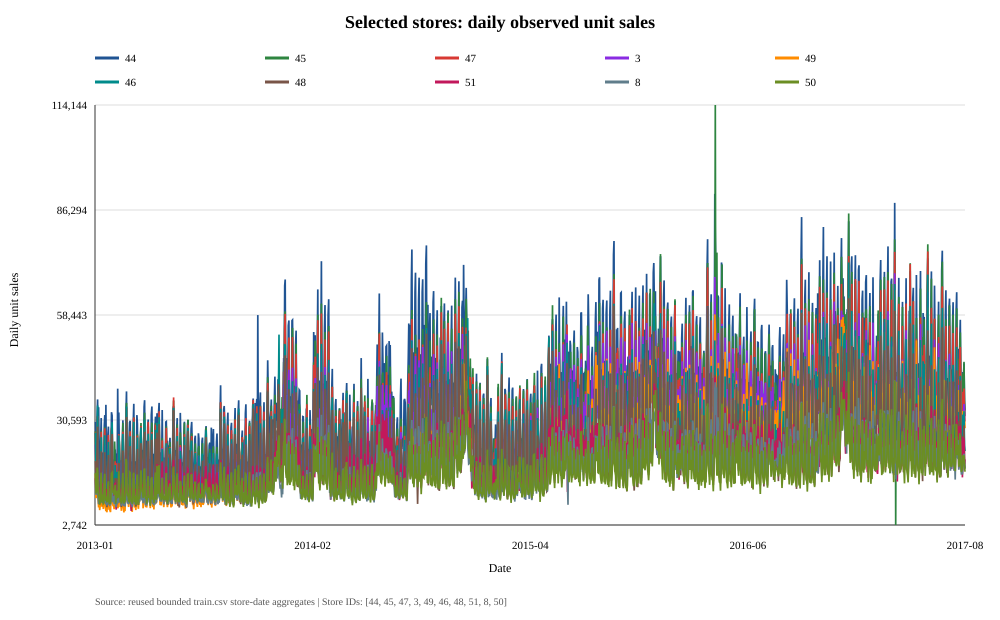

In [14]:
store_daily_behaviour = period_behaviour_summary(
    store_daily_matrix, "store_nbr", "daily", "%Y-%m-%d"
)
display(store_daily_behaviour)

store_daily_svg = build_svg_multi_line_chart(
    store_daily_matrix,
    "Selected stores: daily observed unit sales",
    "Date",
    "Daily unit sales",
    f"Source: reused bounded train.csv store-date aggregates | Store IDs: {analyzed_store_nbrs}",
)
display(SVG(data=store_daily_svg))


### 5.8 Weekly store behaviour

Weekly store comparisons use complete `W-SUN` periods only.


,store_nbr,mean_weekly_sales,median_weekly_sales,weekly_sales_std,minimum_weekly_sales,maximum_weekly_sales,peak_period,peak_period_sales,lowest_period,lowest_period_sales,latest_period,latest_period_sales,previous_period,previous_period_sales,latest_period_change_pct,observed_period_count
0,44,257824.981307,286575.48250,74471.155556,129078.248,438251.997,2016-04-24,438251.997,2013-02-10,129078.248,2017-08-13,267853.703,2017-08-06,320038.800,-0.163059,240
1,45,226282.580368,244345.28950,67798.561089,116792.680,423699.085,2016-04-24,423699.085,2013-01-27,116792.680,2017-08-13,257492.254,2017-08-06,307147.625,-0.161666,240
2,47,211506.717316,226541.45200,61900.428334,106308.546,373165.375,2017-01-08,373165.375,2013-07-14,106308.546,2017-08-13,230842.418,2017-08-06,287486.794,-0.197033,240
3,3,209628.342484,235812.66650,63487.983947,96434.383,348237.441,2017-01-08,348237.441,2013-02-10,96434.383,2017-08-13,219157.671,2017-08-06,255899.847,-0.143580,240
4,49,180391.292748,197010.49225,72587.743558,56928.776,338561.855,2017-01-08,338561.855,2013-02-10,56928.776,2017-08-13,213030.525,2017-08-06,245550.040,-0.132435,240
5,46,173867.271398,176369.60100,44839.818899,101345.115,311459.004,2017-01-08,311459.004,2013-07-21,101345.115,2017-08-13,182156.756,2017-08-06,228338.814,-0.202252,240
6,48,149142.840927,149115.69950,39330.846302,82704.224,271225.916,2017-01-08,271225.916,2013-06-16,82704.224,2017-08-13,156918.109,2017-08-06,208981.454,-0.249129,240
7,51,136678.598834,150315.46800,35164.301428,76029.560,223991.399,2016-04-24,223991.399,2013-03-31,76029.560,2017-08-13,150135.287,2017-08-06,175406.085,-0.144070,240
8,8,126621.681343,143067.01510,37396.550890,64915.555,217337.549,2016-04-24,217337.549,2013-02-10,64915.555,2017-08-13,131114.577,2017-08-06,156847.823,-0.164065,240
9,50,118929.659610,122254.19275,29273.670050,71438.673,200560.627,2016-12-25,200560.627,2013-11-03,71438.673,2017-08-13,133624.292,2017-08-06,157521.713,-0.151709,240


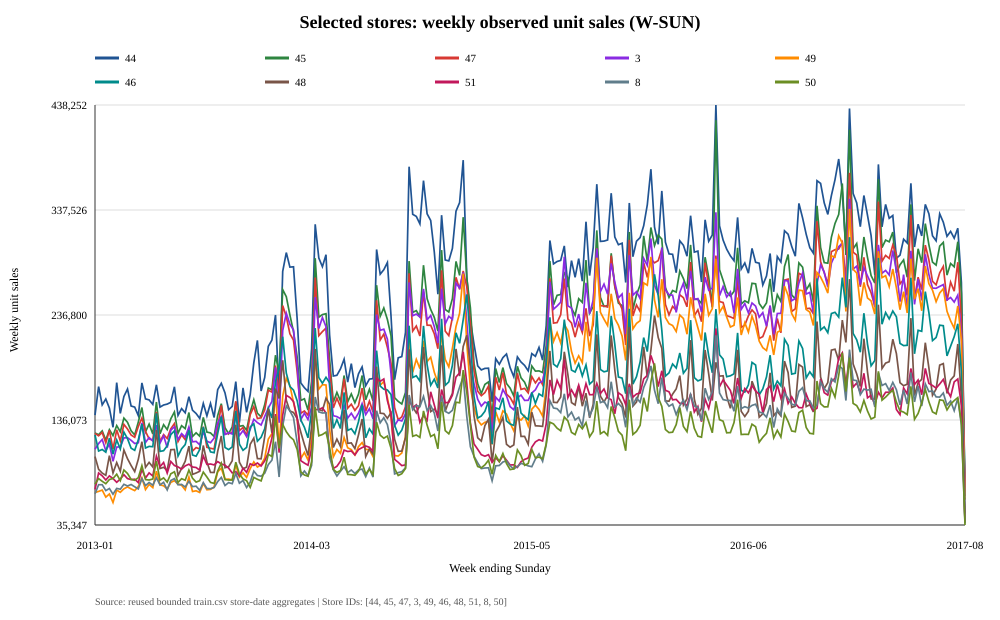

In [15]:
store_weekly_complete = store_weekly_matrix.loc[complete_week_mask(store_weekly_matrix.index)]
store_weekly_behaviour = period_behaviour_summary(
    store_weekly_complete, "store_nbr", "weekly", "%Y-%m-%d"
)
display(store_weekly_behaviour)

store_weekly_svg = build_svg_multi_line_chart(
    store_weekly_matrix,
    "Selected stores: weekly observed unit sales (W-SUN)",
    "Week ending Sunday",
    "Weekly unit sales",
    f"Source: reused bounded train.csv store-date aggregates | Store IDs: {analyzed_store_nbrs}",
)
display(SVG(data=store_weekly_svg))


### 5.9 Monthly store behaviour

August 2017 remains visible and labelled as partial in the graph, but complete-month store statistics exclude it.


,store_nbr,mean_monthly_sales,median_monthly_sales,monthly_sales_std,minimum_monthly_sales,maximum_monthly_sales,peak_period,peak_period_sales,lowest_period,lowest_period_sales,latest_period,latest_period_sales,previous_period,previous_period_sales,latest_period_change_pct,observed_period_count
0,44,1.117694e+06,1249068.241,322565.504473,595527.551,1633582.053,2016-12,1633582.053,2013-02,595527.551,2017-07,1453714.555,2017-06,1371338.338,0.060070,55
1,45,9.801532e+05,1106314.950,289833.537242,503479.820,1525535.322,2016-12,1525535.322,2013-02,503479.820,2017-07,1329122.799,2017-06,1265034.873,0.050661,55
2,47,9.164510e+05,999969.106,265859.557554,477916.974,1375002.948,2016-12,1375002.948,2013-02,477916.974,2017-07,1223398.942,2017-06,1187572.874,0.030167,55
3,3,9.086910e+05,1034288.412,277640.394733,429618.649,1344791.126,2016-12,1344791.126,2013-02,429618.649,2017-07,1159554.559,2017-06,1151367.772,0.007110,55
4,49,7.806760e+05,863972.399,316861.003780,258320.142,1332932.755,2016-12,1332932.755,2013-02,258320.142,2017-07,1093551.249,2017-06,1117084.224,-0.021066,55
5,46,7.539921e+05,798268.831,184481.741513,446971.842,1159007.774,2016-12,1159007.774,2013-02,446971.842,2017-07,991521.072,2017-06,965123.641,0.027351,55
6,48,6.465011e+05,681730.927,156145.430753,369976.821,986438.137,2016-12,986438.137,2013-02,369976.821,2017-07,832163.973,2017-06,752878.634,0.105310,55
7,51,5.921747e+05,651216.215,155965.953038,318236.043,847147.806,2016-12,847147.806,2013-02,318236.043,2017-07,758039.999,2017-06,728487.374,0.040567,55
8,8,5.488588e+05,633394.855,164107.013340,274554.327,814571.063,2016-12,814571.063,2013-02,274554.327,2017-07,695955.132,2017-06,689738.275,0.009013,55
9,50,5.154143e+05,550437.622,125823.598091,323027.228,815042.305,2016-12,815042.305,2013-02,323027.228,2017-07,697939.893,2017-06,635674.347,0.097952,55


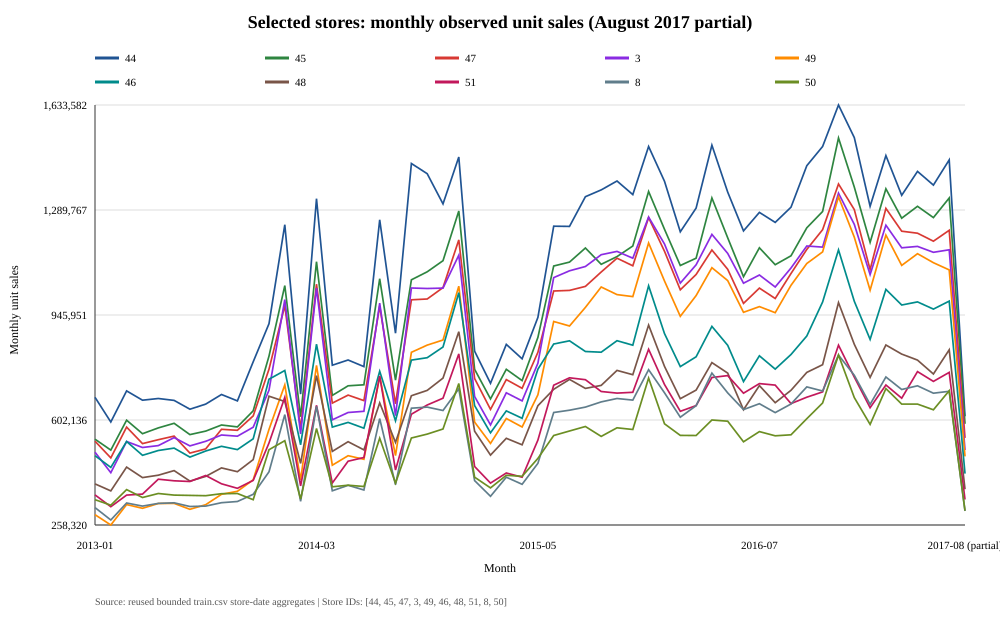

In [16]:
store_monthly_complete = store_monthly_matrix.loc[complete_month_mask(store_monthly_matrix.index)]
store_monthly_behaviour = period_behaviour_summary(
    store_monthly_complete, "store_nbr", "monthly", "%Y-%m"
)
display(store_monthly_behaviour)

store_monthly_svg = build_svg_multi_line_chart(
    store_monthly_matrix,
    "Selected stores: monthly observed unit sales (August 2017 partial)",
    "Month",
    "Monthly unit sales",
    f"Source: reused bounded train.csv store-date aggregates | Store IDs: {analyzed_store_nbrs}",
    partial_final_month=True,
)
display(SVG(data=store_monthly_svg))


**Interpretation:** product and store patterns can diverge from company-wide totals, and individual products can peak during an aggregate decline. These top-N series are bounded descriptive examples only. Missing source rows are not assumed to be zero demand, August 2017 is partial, no causal interpretation is supported, and the final forecasting grain remains unapproved.


### 6. Store, item, family, and store-item concentration


In [17]:
def concentration_summary(series: pd.Series, prefix: str) -> dict:
    ordered = series.sort_values(ascending=False)
    total = float(ordered.sum())
    return {
        f"{prefix}_count": int(len(ordered)),
        f"{prefix}_top_1_share": float(ordered.iloc[:1].sum() / total),
        f"{prefix}_top_10_share": float(ordered.iloc[:10].sum() / total),
        f"{prefix}_top_20_percent_share": float(ordered.iloc[:max(1, math.ceil(len(ordered) * 0.20))].sum() / total),
    }

store_concentration = concentration_summary(store_sales, "store")
item_concentration = concentration_summary(item_sales, "item")
family_concentration = concentration_summary(family_sales, "family")

train_start = pd.Timestamp(daily.index.min())
train_end = pd.Timestamp(daily.index.max())
calendar_days = (train_end - train_start).days + 1
observed_series = pd.DataFrame({"observed_rows": store_item_rows, "unit_sales": store_item_sales})
observed_series["first_date"] = [series_first[key] for key in observed_series.index]
observed_series["last_date"] = [series_last[key] for key in observed_series.index]
observed_series["history_span_days"] = (
    pd.to_datetime(observed_series["last_date"]) - pd.to_datetime(observed_series["first_date"])
).dt.days + 1
observed_series["observed_day_share_of_span"] = observed_series["observed_rows"] / observed_series["history_span_days"]
short_history_count = int(((observed_series["history_span_days"] < 180) | (observed_series["observed_rows"] < 60)).sum())
intermittent_proxy_count = int((observed_series["observed_day_share_of_span"] < 0.25).sum())

item_coverage = pd.DataFrame({
    "first_date": pd.Series(item_first),
    "last_date": pd.Series(item_last),
    "observed_rows": item_rows,
    "unit_sales": item_sales,
})
recent_cutoff = train_end - pd.Timedelta(days=90)
new_item_count = int((pd.to_datetime(item_coverage["first_date"]) > recent_cutoff).sum())
inactive_item_count = int((pd.to_datetime(item_coverage["last_date"]) < recent_cutoff).sum())

print(json.dumps({
    **store_concentration,
    **item_concentration,
    **family_concentration,
    "calendar_days": calendar_days,
    "observed_store_item_series": len(observed_series),
    "median_observed_rows_per_series": float(observed_series["observed_rows"].median()),
    "median_observed_day_share_of_span": float(observed_series["observed_day_share_of_span"].median()),
    "short_history_series_count_candidate_rule": short_history_count,
    "intermittent_series_count_proxy": intermittent_proxy_count,
    "new_items_first_seen_in_final_90_days": new_item_count,
    "inactive_items_not_seen_in_final_90_days": inactive_item_count,
    "literal_zero_sales_rows": zero_rows,
}, indent=2))


{
  "store_count": 54,
  "store_top_1_share": 0.05783061699260966,
  "store_top_10_share": 0.40174808747889407,
  "store_top_20_percent_share": 0.4281315501797325,
  "item_count": 4036,
  "item_top_1_share": 0.0058347055143882255,
  "item_top_10_share": 0.04255292141773443,
  "item_top_20_percent_share": 0.6112154477645927,
  "family_count": 33,
  "family_top_1_share": 0.31991285652828033,
  "family_top_10_share": 0.9304139682027703,
  "family_top_20_percent_share": 0.8561060594617559,
  "calendar_days": 1688,
  "observed_store_item_series": 174685,
  "median_observed_rows_per_series": 651.0,
  "median_observed_day_share_of_span": 0.7045685279187818,
  "short_history_series_count_candidate_rule": 19283,
  "intermittent_series_count_proxy": 21733,
  "new_items_first_seen_in_final_90_days": 59,
  "inactive_items_not_seen_in_final_90_days": 107,
  "literal_zero_sales_rows": 0
}


**Interpretation boundary:** `observed_day_share_of_span` is a coverage proxy. Because the source contains no literal zero-sales rows, gaps may represent zero demand, assortment status, or source recording rules. It is not an approved intermittency label.


### 7. Promotion, holidays, transactions, and oil alignment


In [18]:
promotion = pd.DataFrame({"rows": promotion_rows, "unit_sales": promotion_sales})
promotion["mean_unit_sales_per_observed_row"] = promotion["unit_sales"] / promotion["rows"]

holiday_daily = holidays.groupby("date").agg(
    event_records=("description", "size"),
    transferred_records=("transferred", lambda values: int(values.fillna(False).sum())),
)
holiday_daily = holiday_daily.astype({"event_records": "int64", "transferred_records": "int64"})
daily_context = daily.join(holiday_daily, how="left").fillna({"event_records": 0, "transferred_records": 0})
daily_context["has_event_record"] = daily_context["event_records"] > 0
holiday_descriptive = daily_context.groupby("has_event_record")["unit_sales"].agg(["count", "mean", "median"])

daily_store = daily_store_sales.rename("unit_sales").reset_index()
daily_store["date"] = pd.to_datetime(daily_store["date"])
transaction_alignment = daily_store.merge(transactions, on=["date", "store_nbr"], how="left", validate="one_to_one")
transaction_coverage = float(transaction_alignment["transactions"].notna().mean())
transaction_correlation = float(transaction_alignment[["unit_sales", "transactions"]].corr().iloc[0, 1])

oil_alignment = daily.reset_index(names="date").merge(oil, on="date", how="left", validate="one_to_one")
oil_coverage = float(oil_alignment["dcoilwtico"].notna().mean())
oil_correlation = float(oil_alignment[["unit_sales", "dcoilwtico"]].corr().iloc[0, 1])

print("Promotion descriptive behaviour (not a causal effect):")
print(promotion.to_string())
print("\nHoliday/event date comparison (date-level aggregation avoids join multiplication):")
print(holiday_descriptive.to_string())
print(json.dumps({
    "holiday_records": len(holidays),
    "holiday_dates": int(holidays["date"].nunique()),
    "transferred_holiday_records": int(holidays["transferred"].fillna(False).sum()),
    "transaction_store_day_coverage": transaction_coverage,
    "sales_transaction_pearson_correlation": transaction_correlation,
    "oil_daily_coverage": oil_coverage,
    "sales_oil_pearson_correlation": oil_correlation,
}, indent=2))


Promotion descriptive behaviour (not a causal effect):
                 rows    unit_sales  mean_unit_sales_per_observed_row
promotion                                                            
False      96028767.0  7.766937e+08                          8.088135
True        7810622.0  1.051830e+08                         13.466666
missing    21657651.0  1.917336e+08                          8.852925

Holiday/event date comparison (date-level aggregation avoids join multiplication):
                  count           mean       median
has_event_record                                   
False              1432  627536.722316  624853.7476
True                252  694355.882662  680788.3720
{
  "holiday_records": 350,
  "holiday_dates": 312,
  "transferred_holiday_records": 12,
  "transaction_store_day_coverage": 0.9985886180417674,
  "sales_transaction_pearson_correlation": 0.8373659141397505,
  "oil_daily_coverage": 0.6906175771971497,
  "sales_oil_pearson_correlation": -0.7050289525639

Correlations and promoted/non-promoted means are descriptive associations only. They do not control for store, item, season, assortment, price, missingness, or promotion selection.


### 8. Display inline aggregate research plots


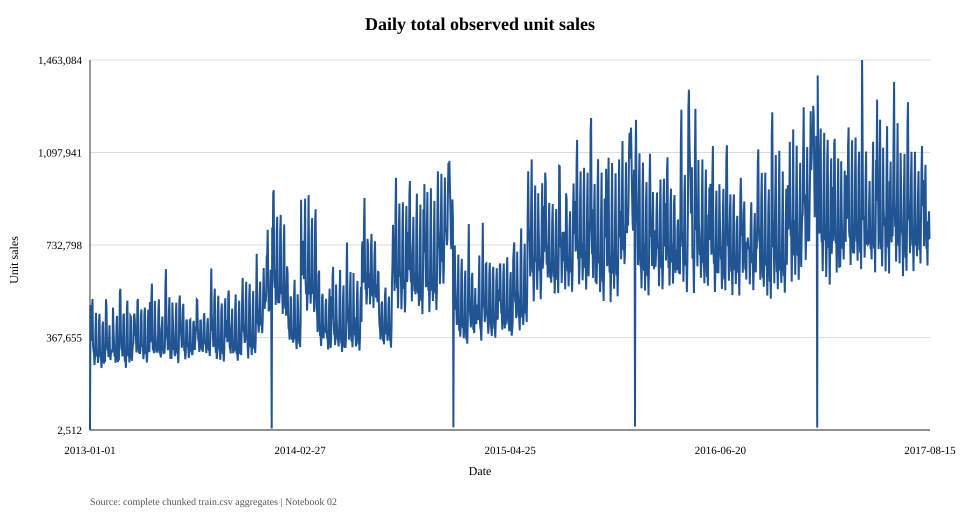

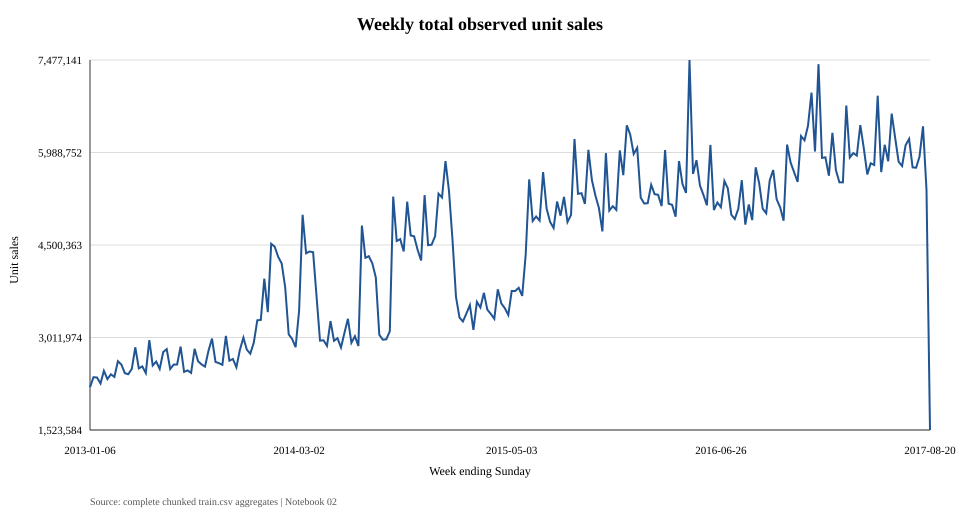

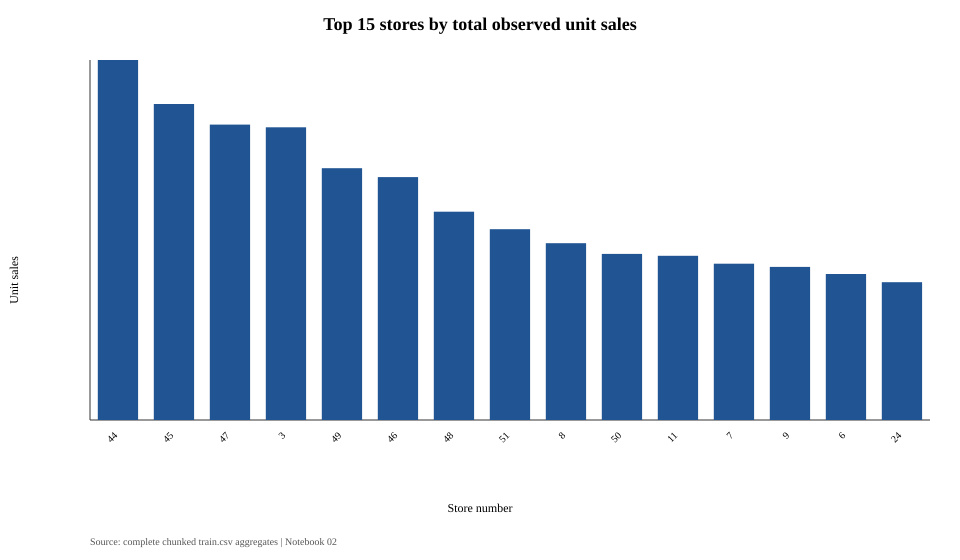

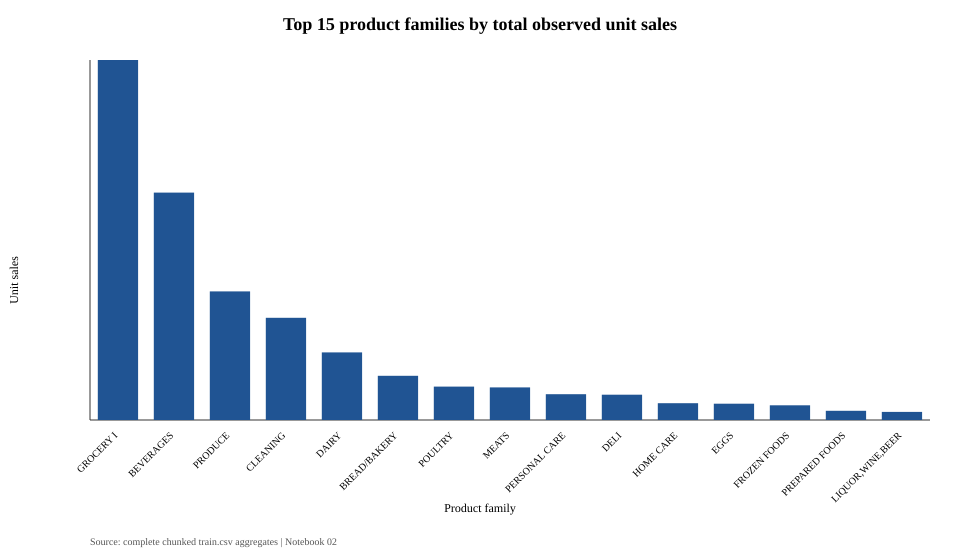

Interpretation: inline daily/weekly charts expose time variation; inline concentration charts show where observed sales mass lies. Review visible shapes before asserting seasonality or breaks.


In [19]:
source_note = "Source: complete chunked train.csv aggregates | Notebook 02"

daily_total_svg = build_svg_line_chart(
    daily.index.strftime("%Y-%m-%d").tolist(),
    daily["unit_sales"].tolist(),
    "Daily total observed unit sales",
    "Date",
    "Unit sales",
    source_note,
)
display(SVG(data=daily_total_svg))

weekly_total_svg = build_svg_line_chart(
    weekly.index.strftime("%Y-%m-%d").tolist(),
    weekly.tolist(),
    "Weekly total observed unit sales",
    "Week ending Sunday",
    "Unit sales",
    source_note,
)
display(SVG(data=weekly_total_svg))

top_stores = store_sales.sort_values(ascending=False).head(15)
top_stores_svg = build_svg_bar_chart(
    [str(value) for value in top_stores.index],
    top_stores.tolist(),
    "Top 15 stores by total observed unit sales",
    "Store number",
    "Unit sales",
    source_note,
)
display(SVG(data=top_stores_svg))

top_families = family_sales.sort_values(ascending=False).head(15)
top_families_svg = build_svg_bar_chart(
    [str(value) for value in top_families.index],
    top_families.tolist(),
    "Top 15 product families by total observed unit sales",
    "Product family",
    "Unit sales",
    source_note,
)
display(SVG(data=top_families_svg))

print("Interpretation: inline daily/weekly charts expose time variation; inline concentration charts show where observed sales mass lies. Review visible shapes before asserting seasonality or breaks.")


## Takeaways

- Full chunked aggregates support temporal, store, item, family, promotion, and observed-series coverage findings; no raw record artifact is retained.
- Store-item sparsity and inactivity rules remain candidate definitions because absent observations do not have a verified zero-demand meaning.
- Promotion, holiday, transaction, and oil relationships are descriptive and must not be presented as causal.
- Candidate structural breaks require visual review and domain context; large month-to-month movements alone are not proof of a regime change.
- Tables and graphs remain inline in Notebook 02; this notebook does not write JSON, SVG, PNG, or other external EDA report files.
- Notebook 03 remains unchanged. Preprocessing, feature engineering, and modelling remain blocked pending approval.
